# Baseline: Multinomial Logistic Regression

This notebook implements Multinomial Logistic Regression (Softmax Regression) with:
- Feature standardization using StandardScaler
- L2 regularization
- Three datasets: Candle, Orderbook, and Combined

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    balanced_accuracy_score,
    f1_score
)
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
# Define data paths
data_path = Path('..') / 'Processed_Data' / 'dataset_candle.parquet'
data_combined_path = Path('..') / 'Processed_Data' / 'dataset_combined.parquet'
data_orderbook_path = Path('..') / 'Processed_Data' / 'dataset_orderbook.parquet'

print('Reading datasets...')
print('  -', data_path.resolve())
print('  -', data_combined_path.resolve())
print('  -', data_orderbook_path.resolve())

# Load datasets
data_candle = pd.read_parquet(data_path)
data_combined = pd.read_parquet(data_combined_path)
data_orderbook = pd.read_parquet(data_orderbook_path)

print('\n✓ Datasets loaded successfully')
print(f'  Candle shape: {data_candle.shape}')
print(f'  Orderbook shape: {data_orderbook.shape}')
print(f'  Combined shape: {data_combined.shape}')

Reading datasets...
  - /Users/dyujoymajumdar/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/Year 1/Quarter 2/DSAIT4020 Elements of Stastical Learning/repos/esl/Processed_Data/dataset_candle.parquet
  - /Users/dyujoymajumdar/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/Year 1/Quarter 2/DSAIT4020 Elements of Stastical Learning/repos/esl/Processed_Data/dataset_combined.parquet
  - /Users/dyujoymajumdar/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/Year 1/Quarter 2/DSAIT4020 Elements of Stastical Learning/repos/esl/Processed_Data/dataset_orderbook.parquet

✓ Datasets loaded successfully
  Candle shape: (40302, 18)
  Orderbook shape: (40302, 7)
  Combined shape: (40302, 24)


## Data Preparation Function

Function to prepare data with train/val/test split and feature standardization.

In [3]:
def prepare_data(data, dataset_name):
    """
    Prepare dataset for Logistic Regression:
    - Clean columns
    - Map target values to 0, 1, 2
    - Split into train/val/test
    - Standardize features
    
    Returns:
        Dictionary with train/val/test splits and scaler
    """
    print(f"\n{'='*70}")
    print(f"Preparing {dataset_name} dataset")
    print(f"{'='*70}")
    
    # Drop unnecessary columns if they exist
    cols_to_drop = ['ignore', 'close_time']
    data_clean = data.drop(columns=[c for c in cols_to_drop if c in data.columns], errors='ignore')
    
    # Separate features and target
    X = data_clean.drop(columns=['target'])
    y_raw = data_clean['target']
    
    # Map target: -1 -> 0 (down), 0 -> 1 (flat), 1 -> 2 (up)
    y = y_raw.map({-1: 0, 0: 1, 1: 2}).astype(int)
    
    print(f"Features: {X.shape[1]}")
    print(f"Samples: {len(X)}")
    print(f"Target distribution:")
    print(y.value_counts(normalize=True).sort_index())
    
    # Time-based split with gap
    gap = 5  # minutes gap to avoid data leakage
    n = len(X)
    train_end = int(n * 0.7)
    val_end = int(n * 0.85)
    
    # Split data
    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]
    
    X_val = X.iloc[train_end+gap:val_end]
    y_val = y.iloc[train_end+gap:val_end]
    
    X_test = X.iloc[val_end+gap:]
    y_test = y.iloc[val_end+gap:]
    
    print(f"\nSplit sizes:")
    print(f"  Train: {len(X_train)} ({len(X_train)/n*100:.1f}%)")
    print(f"  Val:   {len(X_val)} ({len(X_val)/n*100:.1f}%)")
    print(f"  Test:  {len(X_test)} ({len(X_test)/n*100:.1f}%)")
    
    # Standardize features using training data statistics
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    print("\n✓ Features standardized (mean=0, std=1)")
    
    return {
        'X_train': X_train_scaled,
        'y_train': y_train,
        'X_val': X_val_scaled,
        'y_val': y_val,
        'X_test': X_test_scaled,
        'y_test': y_test,
        'scaler': scaler,
        'feature_names': X.columns.tolist()
    }

## Multinomial Logistic Regression Training Function

Function to train and evaluate Logistic Regression with L2 regularization.

In [4]:
def train_logistic_regression(data_dict, dataset_name, C_values=[0.001, 0.01, 0.1, 1.0, 10.0]):
    """
    Train Multinomial Logistic Regression with L2 regularization.
    Tune regularization strength C on validation set.
    
    Parameters:
        data_dict: Dictionary with train/val/test splits
        dataset_name: Name of the dataset
        C_values: List of inverse regularization strengths to try
    
    Returns:
        Dictionary with best model and results
    """
    print(f"\n{'='*70}")
    print(f"Training Logistic Regression on {dataset_name}")
    print(f"{'='*70}")
    
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']
    X_val = data_dict['X_val']
    y_val = data_dict['y_val']
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    
    # Hyperparameter tuning: Find best C on validation set
    print(f"\nTuning regularization strength C...")
    print(f"Testing C values: {C_values}")
    
    best_C = None
    best_val_score = -1
    results = []
    
    for C in C_values:
        # Train model with current C
        model = LogisticRegression(
            solver='lbfgs',
            penalty='l2',
            C=C,
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        )
        
        model.fit(X_train, y_train)
        
        # Evaluate on validation set
        y_val_pred = model.predict(X_val)
        val_acc = accuracy_score(y_val, y_val_pred)
        val_bal_acc = balanced_accuracy_score(y_val, y_val_pred)
        val_f1 = f1_score(y_val, y_val_pred, average='macro')
        
        results.append({
            'C': C,
            'val_acc': val_acc,
            'val_bal_acc': val_bal_acc,
            'val_f1': val_f1
        })
        
        print(f"  C={C:6.3f} | Val Acc: {val_acc:.4f} | Val Bal Acc: {val_bal_acc:.4f} | Val F1: {val_f1:.4f}")
        
        # Track best based on balanced accuracy
        if val_bal_acc > best_val_score:
            best_val_score = val_bal_acc
            best_C = C
    
    print(f"\n✓ Best C: {best_C} (Val Balanced Acc: {best_val_score:.4f})")
    
    # Train final model with best C on train+val data
    print(f"\nRetraining on train+val data with best C={best_C}...")
    
    # Combine train and val
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])
    
    final_model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        C=best_C,
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    
    final_model.fit(X_trainval, y_trainval)
    
    # Evaluate on test set
    y_test_pred = final_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    print(f"\n{'='*70}")
    print(f"Test Set Results")
    print(f"{'='*70}")
    print(f"Accuracy:          {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro F1 Score:    {test_f1:.4f}")
    
    # Confusion matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_test_pred, 
                                digits=4, 
                                target_names=['down', 'flat', 'up']))
    
    return {
        'model': final_model,
        'best_C': best_C,
        'best_val_score': best_val_score,
        'test_acc': test_acc,
        'test_bal_acc': test_bal_acc,
        'test_f1': test_f1,
        'y_test_pred': y_test_pred,
        'confusion_matrix': cm,
        'tuning_results': results
    }

## Model 1: Candle Dataset

Train Logistic Regression on OHLCV candle features.

In [5]:
# Prepare candle data
# Convert object columns to numeric
obj_cols = ["quote_asset_volume", "taker_buy_base", "taker_buy_quote", "ignore"]
for col in obj_cols:
    if col in data_candle.columns:
        data_candle[col] = pd.to_numeric(data_candle[col], errors="coerce")

candle_data = prepare_data(data_candle.copy(), "Candle")

# Train model
candle_results = train_logistic_regression(candle_data, "Candle")


Preparing Candle dataset
Features: 15
Samples: 40302
Target distribution:
target
0    0.326088
1    0.345541
2    0.328371
Name: proportion, dtype: float64

Split sizes:
  Train: 28211 (70.0%)
  Val:   6040 (15.0%)
  Test:  6041 (15.0%)

✓ Features standardized (mean=0, std=1)

Training Logistic Regression on Candle

Tuning regularization strength C...
Testing C values: [0.001, 0.01, 0.1, 1.0, 10.0]
  C= 0.001 | Val Acc: 0.4230 | Val Bal Acc: 0.4042 | Val F1: 0.3524
  C= 0.010 | Val Acc: 0.4235 | Val Bal Acc: 0.4054 | Val F1: 0.3568
  C= 0.100 | Val Acc: 0.4253 | Val Bal Acc: 0.4071 | Val F1: 0.3615
  C= 1.000 | Val Acc: 0.4255 | Val Bal Acc: 0.4073 | Val F1: 0.3617
  C=10.000 | Val Acc: 0.4258 | Val Bal Acc: 0.4075 | Val F1: 0.3619

✓ Best C: 10.0 (Val Balanced Acc: 0.4075)

Retraining on train+val data with best C=10.0...

Test Set Results
Accuracy:          0.5446
Balanced Accuracy: 0.4465
Macro F1 Score:    0.4334

Confusion Matrix:
[[ 352  936  287]
 [ 153 2581  179]
 [ 327  869 

## Model 2: Orderbook Dataset

Train Logistic Regression on orderbook microstructure features.

In [6]:
# Prepare orderbook data
orderbook_data = prepare_data(data_orderbook.copy(), "Orderbook")

# Train model
orderbook_results = train_logistic_regression(orderbook_data, "Orderbook")


Preparing Orderbook dataset
Features: 6
Samples: 40302
Target distribution:
target
0    0.326088
1    0.345541
2    0.328371
Name: proportion, dtype: float64

Split sizes:
  Train: 28211 (70.0%)
  Val:   6040 (15.0%)
  Test:  6041 (15.0%)

✓ Features standardized (mean=0, std=1)

Training Logistic Regression on Orderbook

Tuning regularization strength C...
Testing C values: [0.001, 0.01, 0.1, 1.0, 10.0]
  C= 0.001 | Val Acc: 0.4108 | Val Bal Acc: 0.3985 | Val F1: 0.3465
  C= 0.010 | Val Acc: 0.4108 | Val Bal Acc: 0.3985 | Val F1: 0.3494
  C= 0.100 | Val Acc: 0.4118 | Val Bal Acc: 0.3996 | Val F1: 0.3527
  C= 1.000 | Val Acc: 0.4114 | Val Bal Acc: 0.3992 | Val F1: 0.3524
  C=10.000 | Val Acc: 0.4109 | Val Bal Acc: 0.3987 | Val F1: 0.3520

✓ Best C: 0.1 (Val Balanced Acc: 0.3996)

Retraining on train+val data with best C=0.1...

Test Set Results
Accuracy:          0.5271
Balanced Accuracy: 0.4469
Macro F1 Score:    0.4282

Confusion Matrix:
[[ 635  764  176]
 [ 386 2341  186]
 [ 649  6

## Model 3: Combined Dataset

Train Logistic Regression on combined candle + orderbook features.

In [7]:
# Prepare combined data
combined_data = prepare_data(data_combined.copy(), "Combined")

# Train model
combined_results = train_logistic_regression(combined_data, "Combined")


Preparing Combined dataset
Features: 21
Samples: 40302
Target distribution:
target
0    0.326088
1    0.345541
2    0.328371
Name: proportion, dtype: float64

Split sizes:
  Train: 28211 (70.0%)
  Val:   6040 (15.0%)
  Test:  6041 (15.0%)

✓ Features standardized (mean=0, std=1)

Training Logistic Regression on Combined

Tuning regularization strength C...
Testing C values: [0.001, 0.01, 0.1, 1.0, 10.0]
  C= 0.001 | Val Acc: 0.4248 | Val Bal Acc: 0.4079 | Val F1: 0.3635
  C= 0.010 | Val Acc: 0.4247 | Val Bal Acc: 0.4079 | Val F1: 0.3662
  C= 0.100 | Val Acc: 0.4275 | Val Bal Acc: 0.4108 | Val F1: 0.3719
  C= 1.000 | Val Acc: 0.4293 | Val Bal Acc: 0.4125 | Val F1: 0.3746
  C=10.000 | Val Acc: 0.4300 | Val Bal Acc: 0.4132 | Val F1: 0.3756

✓ Best C: 10.0 (Val Balanced Acc: 0.4132)

Retraining on train+val data with best C=10.0...

Test Set Results
Accuracy:          0.5436
Balanced Accuracy: 0.4482
Macro F1 Score:    0.4362

Confusion Matrix:
[[ 399  887  289]
 [ 183 2549  181]
 [ 394  

## Model Comparison Summary

Compare performance across all three datasets.

In [8]:
# Create comparison summary
summary = pd.DataFrame({
    'Dataset': ['Candle', 'Orderbook', 'Combined'],
    'Features': [
        f"{len(candle_data['feature_names'])} (OHLCV)",
        f"{len(orderbook_data['feature_names'])} (Microstructure)",
        f"{len(combined_data['feature_names'])} (OHLCV + Microstructure)"
    ],
    'Best C': [
        candle_results['best_C'],
        orderbook_results['best_C'],
        combined_results['best_C']
    ],
    'Val Balanced Acc': [
        candle_results['best_val_score'],
        orderbook_results['best_val_score'],
        combined_results['best_val_score']
    ],
    'Test Accuracy': [
        candle_results['test_acc'],
        orderbook_results['test_acc'],
        combined_results['test_acc']
    ],
    'Test Balanced Acc': [
        candle_results['test_bal_acc'],
        orderbook_results['test_bal_acc'],
        combined_results['test_bal_acc']
    ],
    'Test Macro F1': [
        candle_results['test_f1'],
        orderbook_results['test_f1'],
        combined_results['test_f1']
    ]
})

print("\n" + "="*100)
print("MULTINOMIAL LOGISTIC REGRESSION - MODEL COMPARISON".center(100))
print("="*100)
print(summary.to_string(index=False))
print("="*100)

# Identify best model
best_idx = summary['Test Balanced Acc'].idxmax()
best_model = summary.loc[best_idx, 'Dataset']
best_score = summary.loc[best_idx, 'Test Balanced Acc']

print(f"\n📊 BEST PERFORMING MODEL: {best_model}")
print(f"   Test Balanced Accuracy: {best_score:.4f}")
print("\n" + "="*100)


                         MULTINOMIAL LOGISTIC REGRESSION - MODEL COMPARISON                         
  Dataset                    Features  Best C  Val Balanced Acc  Test Accuracy  Test Balanced Acc  Test Macro F1
   Candle                  15 (OHLCV)    10.0          0.407539       0.544612           0.446466       0.433402
Orderbook          6 (Microstructure)     0.1          0.399577       0.527065           0.446916       0.428223
 Combined 21 (OHLCV + Microstructure)    10.0          0.413203       0.543619           0.448244       0.436168

📊 BEST PERFORMING MODEL: Combined
   Test Balanced Accuracy: 0.4482



## Visualize Regularization Tuning

Plot validation performance across different C values for each dataset.

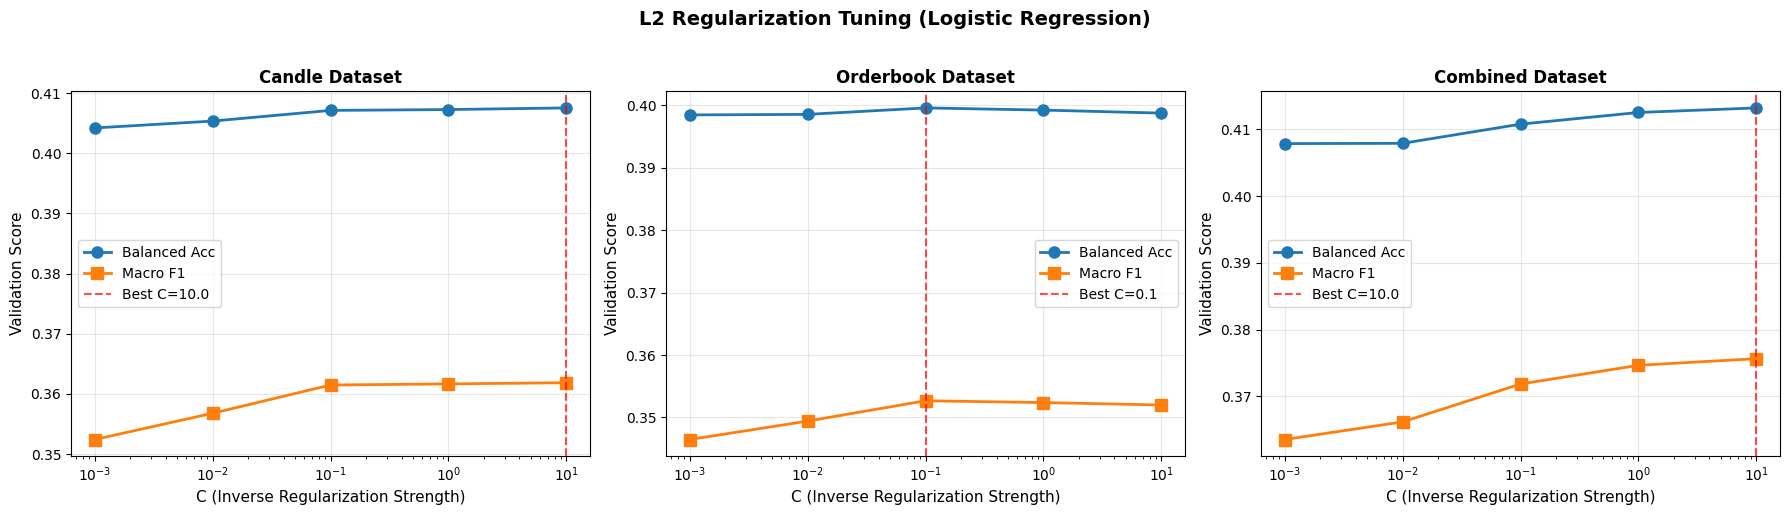

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('Candle', candle_results),
    ('Orderbook', orderbook_results),
    ('Combined', combined_results)
]

for idx, (name, results) in enumerate(datasets):
    df = pd.DataFrame(results['tuning_results'])
    
    ax = axes[idx]
    ax.plot(df['C'], df['val_bal_acc'], 'o-', label='Balanced Acc', linewidth=2, markersize=8)
    ax.plot(df['C'], df['val_f1'], 's-', label='Macro F1', linewidth=2, markersize=8)
    
    # Mark best C
    best_C = results['best_C']
    ax.axvline(best_C, color='red', linestyle='--', alpha=0.7, label=f'Best C={best_C}')
    
    ax.set_xscale('log')
    ax.set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
    ax.set_ylabel('Validation Score', fontsize=11)
    ax.set_title(f'{name} Dataset', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('L2 Regularization Tuning (Logistic Regression)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Analyze the magnitude of coefficients for each class to understand feature importance.


FEATURE IMPORTANCE ANALYSIS


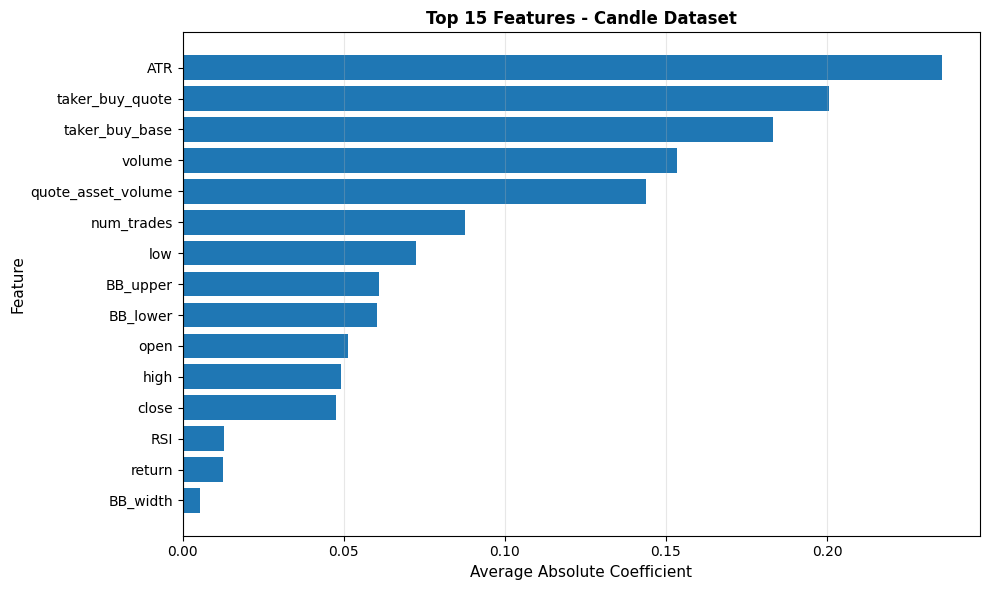

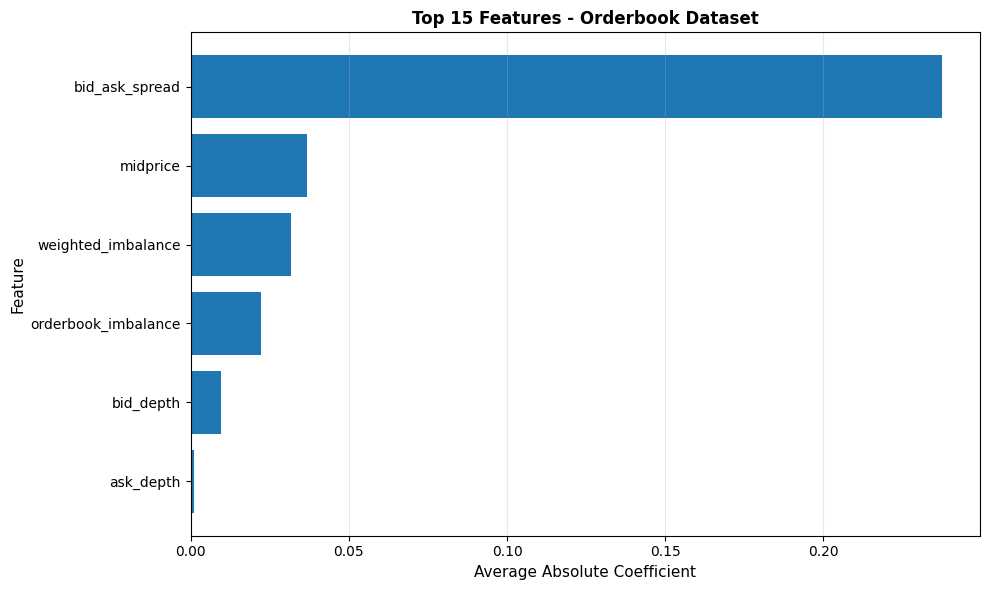

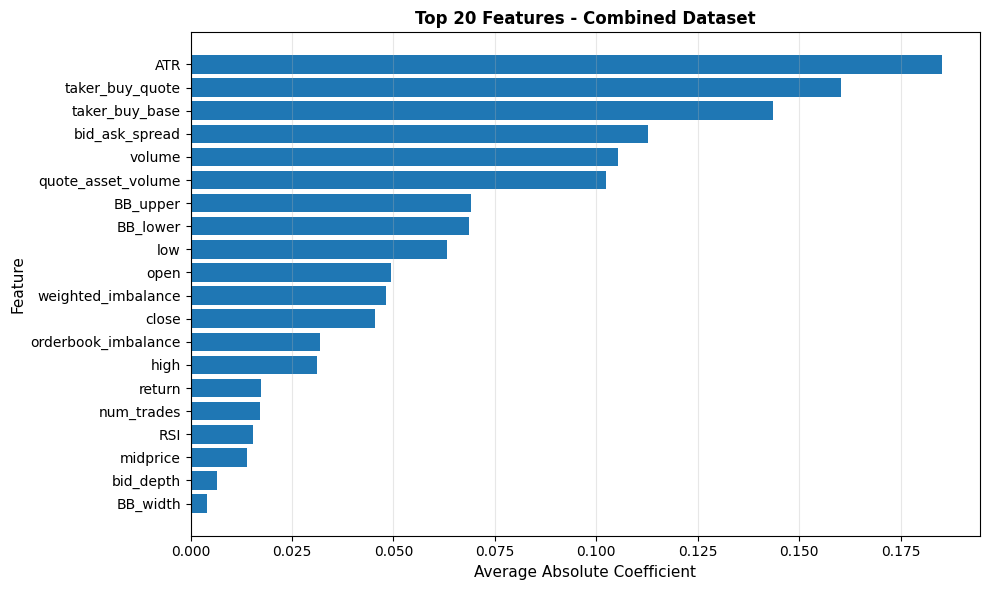

In [10]:
def plot_feature_importance(model, feature_names, dataset_name, top_n=15):
    """
    Plot feature importance based on average absolute coefficient magnitude across classes.
    """
    # Get coefficients for all classes
    coefs = model.coef_  # Shape: (n_classes, n_features)
    
    # Calculate average absolute coefficient across classes
    avg_abs_coef = np.abs(coefs).mean(axis=0)
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': avg_abs_coef
    }).sort_values('importance', ascending=False)
    
    # Plot top N features
    top_features = importance_df.head(top_n)
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Average Absolute Coefficient', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.title(f'Top {top_n} Features - {dataset_name} Dataset', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return importance_df

# Plot for each dataset
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

candle_importance = plot_feature_importance(
    candle_results['model'], 
    candle_data['feature_names'], 
    'Candle'
)

orderbook_importance = plot_feature_importance(
    orderbook_results['model'], 
    orderbook_data['feature_names'], 
    'Orderbook'
)

combined_importance = plot_feature_importance(
    combined_results['model'], 
    combined_data['feature_names'], 
    'Combined',
    top_n=20
)

## Confusion Matrix Visualization

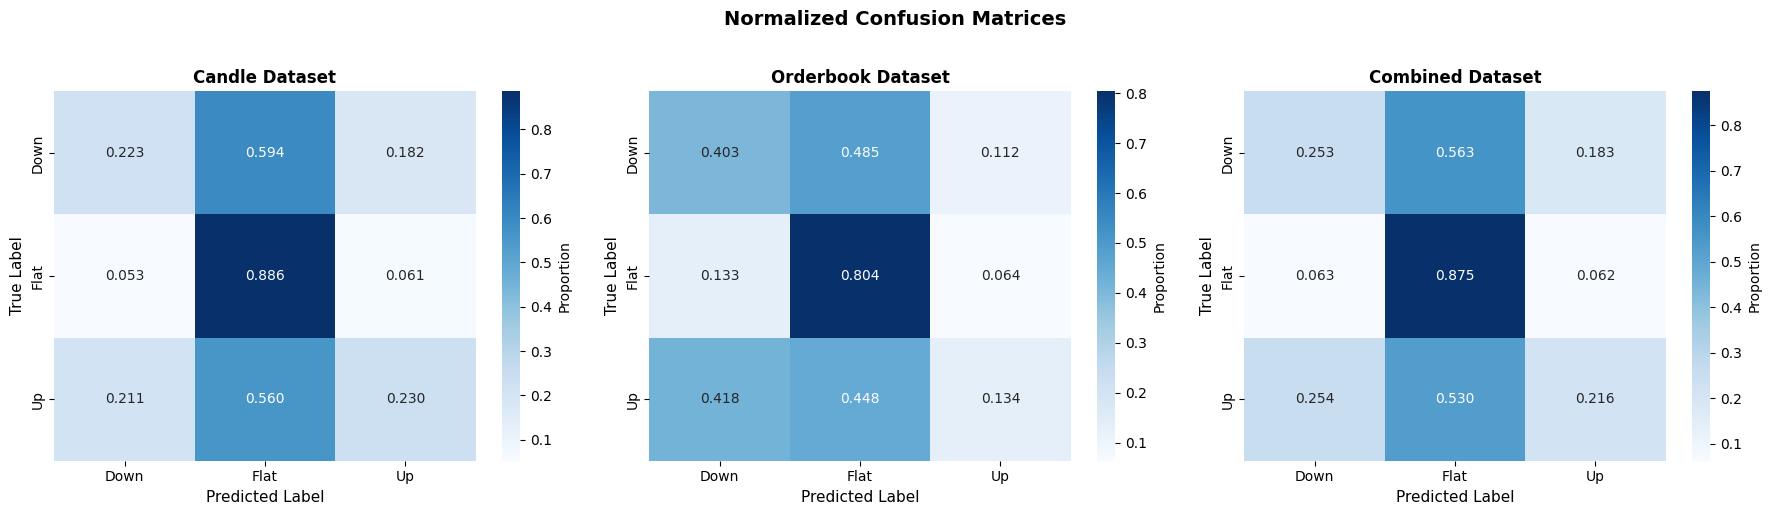

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets_cm = [
    ('Candle', candle_results['confusion_matrix']),
    ('Orderbook', orderbook_results['confusion_matrix']),
    ('Combined', combined_results['confusion_matrix'])
]

for idx, (name, cm) in enumerate(datasets_cm):
    ax = axes[idx]
    
    # Normalize confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', 
                xticklabels=['Down', 'Flat', 'Up'],
                yticklabels=['Down', 'Flat', 'Up'],
                ax=ax, cbar_kws={'label': 'Proportion'})
    
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{name} Dataset', fontsize=12, fontweight='bold')

plt.suptitle('Normalized Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Summary

This notebook implemented Multinomial Logistic Regression (Softmax Regression) with:

**Key Components:**
- Feature standardization using StandardScaler (mean=0, std=1)
- L2 regularization with hyperparameter tuning
- Balanced class weights to handle class imbalance
- Time-based train/val/test split with gap to avoid data leakage

**Models Trained:**
1. **Candle Model**: OHLCV features
2. **Orderbook Model**: Market microstructure features
3. **Combined Model**: All features together

**Evaluation Metrics:**
- Accuracy
- Balanced Accuracy (handles class imbalance)
- Macro F1 Score (equal weight to all classes)

This baseline provides a simple, interpretable model for comparison with more complex approaches like XGBoost.